# Phase 3 — hardware tier comparison

Single-request long-context scaling for **Llama-3.1-8B-Instruct** across hardware tiers (T4 16GB, L4 24GB, A100 40GB, H100 80GB).

one model, batch size 1, four context lengths.

In [1]:
import os

REPO_URL = "https://github.com/sonavk2/LLM_Inference.git"

if not os.path.exists("results"):
    !git clone {REPO_URL}
    repo_name = REPO_URL.rstrip("/").split("/")[-1].replace(".git", "")
    %cd {repo_name}

Cloning into 'LLM_Inference'...
remote: Enumerating objects: 322, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 322 (delta 2), reused 4 (delta 1), pack-reused 309 (from 1)
Receiving objects: 100% (322/322), 3.83 MiB | 9.02 MiB/s, done.
Resolving deltas: 100% (165/165), done.
/content/LLM_Inference


In [3]:
from huggingface_hub import login
login()

## A100 sweep

Runtime → A100 GPU. Reuses Phase 1's A100 result file if it already exists; otherwise re-runs the sweep here.

In [3]:
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --hardware nvidia_a100 \
  --results-path results/phase3_llama31_a100.jsonl

Loading meta-llama/Meta-Llama-3.1-8B-Instruct (dtype=bfloat16, quant=none) on cuda ...
config.json: 100% 855/855 [00:00<00:00, 3.65MB/s]
tokenizer_config.json: 55.4kB [00:00, 46.4MB/s]
tokenizer.json: 9.09MB [00:00, 18.5MB/s]
special_tokens_map.json: 100% 296/296 [00:00<00:00, 1.55MB/s]
model.safetensors.index.json: 23.9kB [00:00, 54.7MB/s]
Fetching 4 files: 100% 4/4 [00:37<00:00,  9.30s/it]
Download complete: 100% 16.1G/16.1G [00:37<00:00, 376MB/s]                
Loading weights:   0% 0/291 [00:00<?, ?it/s]
Loading weights:   0% 1/291 [00:00<00:00, 10407.70it/s, Materializing param=lm_head.weight]
Loading weights:   0% 1/291 [00:00<00:00, 1594.19it/s, Materializing param=lm_head.weight] 
Loading weights:   1% 2/291 [00:00<00:00, 1571.78it/s, Materializing param=model.embed_tokens.weight]
Loading weights:   1% 2/291 [00:00<00:00, 1014.59it/s, Materializing param=model.embed_tokens.weight]
Loading weights:   1% 3/291 [00:00<00:00, 1000.15it/s, Materializing param=model.layers.0.input_l

## L4 sweep

Runtime → L4 GPU (24 GB).

In [4]:
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --hardware nvidia_l4 \
  --results-path results/phase3_llama31_l4.jsonl

Loading meta-llama/Meta-Llama-3.1-8B-Instruct (dtype=bfloat16, quant=none) on cuda ...
config.json: 100% 855/855 [00:00<00:00, 3.86MB/s]
tokenizer_config.json: 55.4kB [00:00, 13.4MB/s]
tokenizer.json: 9.09MB [00:01, 7.63MB/s]
special_tokens_map.json: 100% 296/296 [00:00<00:00, 1.55MB/s]
model.safetensors.index.json: 23.9kB [00:00, 13.8MB/s]
Fetching 4 files: 100% 4/4 [00:47<00:00, 11.80s/it]
Download complete: 100% 16.1G/16.1G [00:47<00:00, 631MB/s]                
Loading weights:   0% 0/291 [00:00<?, ?it/s]
Loading weights:   0% 1/291 [00:00<00:00, 11814.94it/s, Materializing param=lm_head.weight]
Loading weights:   0% 1/291 [00:00<00:00, 859.31it/s, Materializing param=lm_head.weight]  
Loading weights:   1% 2/291 [00:00<00:00, 1254.65it/s, Materializing param=model.embed_tokens.weight]
Loading weights:   1% 2/291 [00:00<00:00, 989.57it/s, Materializing param=model.embed_tokens.weight] 
Loading weights:   1% 3/291 [00:00<00:00, 1125.79it/s, Materializing param=model.layers.0.input_l

## H100 sweep

Runtime → H100 GPU (80 GB). Plenty of headroom;

In [4]:
!python3 scripts/run_context_sweep.py --config configs/baseline_hf.yaml \
  --model-config configs/llama3_1_8b_instruct.yaml \
  --context-lengths 8192 16384 32768 65536 \
  --max-new-tokens 128 \
  --hardware nvidia_h100 \
  --results-path results/phase3_llama31_h100.jsonl

Loading meta-llama/Meta-Llama-3.1-8B-Instruct (dtype=bfloat16, quant=none) on cuda ...
config.json: 100% 855/855 [00:00<00:00, 9.20MB/s]
tokenizer_config.json: 55.4kB [00:00, 27.4MB/s]
tokenizer.json: 9.09MB [00:00, 24.6MB/s]
special_tokens_map.json: 100% 296/296 [00:00<00:00, 3.95MB/s]
model.safetensors.index.json: 23.9kB [00:00, 98.2MB/s]
Fetching 4 files:  25% 1/4 [00:38<01:56, 38.74s/it]
Fetching 4 files: 100% 4/4 [00:38<00:00,  9.73s/it]
Download complete: 100% 16.1G/16.1G [00:38<00:00, 577MB/s]                
Loading weights:   0% 0/291 [00:00<?, ?it/s]
Loading weights:   0% 1/291 [00:00<00:00, 19972.88it/s, Materializing param=lm_head.weight]
Loading weights:   0% 1/291 [00:00<00:00, 6423.13it/s, Materializing param=lm_head.weight] 
Loading weights:   1% 2/291 [00:00<00:00, 8240.28it/s, Materializing param=model.embed_tokens.weight]
Loading weights:   1% 2/291 [00:00<00:00, 7483.15it/s, Materializing param=model.embed_tokens.weight]
Loading weights:   1% 3/291 [00:00<00:00, 887

## T4 — recorded as load-OOM rows

T4 has 16 GB and Llama-3.1-8B bf16 weights are ~16 GB, so the model can't load before any KV cache is allocated. This cell records that finding directly without running the sweep. Switch to a T4 runtime first if you want to verify the OOM live;

In [5]:
import json

err = ('CUDA OOM at model load: bf16 weights ~16 GB exceed T4 free memory '
       '(14.56 GB total). Llama-3.1-8B in bf16 cannot load on T4; INT8 or '
       'INT4 quantization is required before any context-length sweep.')

with open('results/phase3_llama31_t4.jsonl', 'w') as f:
    for ctx in [8192, 16384, 32768, 65536]:
        f.write(json.dumps({
            'model_name': 'meta-llama/Meta-Llama-3.1-8B-Instruct',
            'backend': 'huggingface',
            'hardware': 'nvidia_t4',
            'context_length': ctx, 'batch_size': 1, 'max_new_tokens': 128,
            'ttft_seconds': None, 'tpot_seconds': None,
            'total_latency_seconds': None, 'tokens_per_second': None,
            'peak_gpu_memory_gb': None, 'kv_cache_memory_gb': None,
            'success': False, 'error': err,
            'prompt_format': 'synthetic_repeat',
            'is_native_context': ctx <= 32768,
            'image_token_count': None, 'text_token_count': None,
            'quantization': None,
        }) + '\n')
print('T4 finding recorded as 4 load-OOM rows in results/phase3_llama31_t4.jsonl')

T4 finding recorded as 4 load-OOM rows in results/phase3_llama31_t4.jsonl


## Cross-tier comparison

Loads every `results/phase3_*.jsonl` and produces:
- A summary table (one row per hardware × context).
- A 2×3 metrics plot: TTFT, TPOT, throughput, total latency, peak GPU memory, KV-cache estimate vs. context length, one line per hardware tier.
- A memory-frontier matrix (hardware × context, green = OK, red = OOM).

In [7]:
import json, glob
from pathlib import Path
import pandas as pd

rows = []
for path in sorted(glob.glob('results/phase3_*.jsonl')):
    for line in open(path):
        r = json.loads(line)
        r['_source'] = Path(path).name
        rows.append(r)
if not rows:
    raise SystemExit('No results/phase3_*.jsonl files found yet.')

df = pd.DataFrame(rows)

TIER_ORDER = ['nvidia_t4', 'nvidia_l4', 'nvidia_a100', 'nvidia_h100']
def tier_key(hw):
    return TIER_ORDER.index(hw) if hw in TIER_ORDER else len(TIER_ORDER)
df['tier_rank'] = df['hardware'].map(tier_key)

print(f'loaded {len(df)} rows from {df["_source"].nunique()} files')
print(df.sort_values(['tier_rank', 'context_length'])
        [['hardware', 'context_length', 'success', 'ttft_seconds',
          'total_latency_seconds', 'peak_gpu_memory_gb', 'kv_cache_memory_gb']]
      .to_string(index=False))

loaded 16 rows from 4 files
   hardware  context_length  success  ttft_seconds  total_latency_seconds  peak_gpu_memory_gb  kv_cache_memory_gb
  nvidia_t4            8192    False           NaN                    NaN                 NaN                 NaN
  nvidia_t4           16384    False           NaN                    NaN                 NaN                 NaN
  nvidia_t4           32768    False           NaN                    NaN                 NaN                 NaN
  nvidia_t4           65536    False           NaN                    NaN                 NaN                 NaN
  nvidia_l4            8192     True      3.652752              13.059966           18.120388            1.073742
  nvidia_l4           16384     True      6.044104              17.261997           20.171730            2.147484
  nvidia_l4           32768    False           NaN                    NaN           22.126931            4.294967
  nvidia_l4           65536    False           NaN          

saved results/plots/phase3_hardware_comparison.png


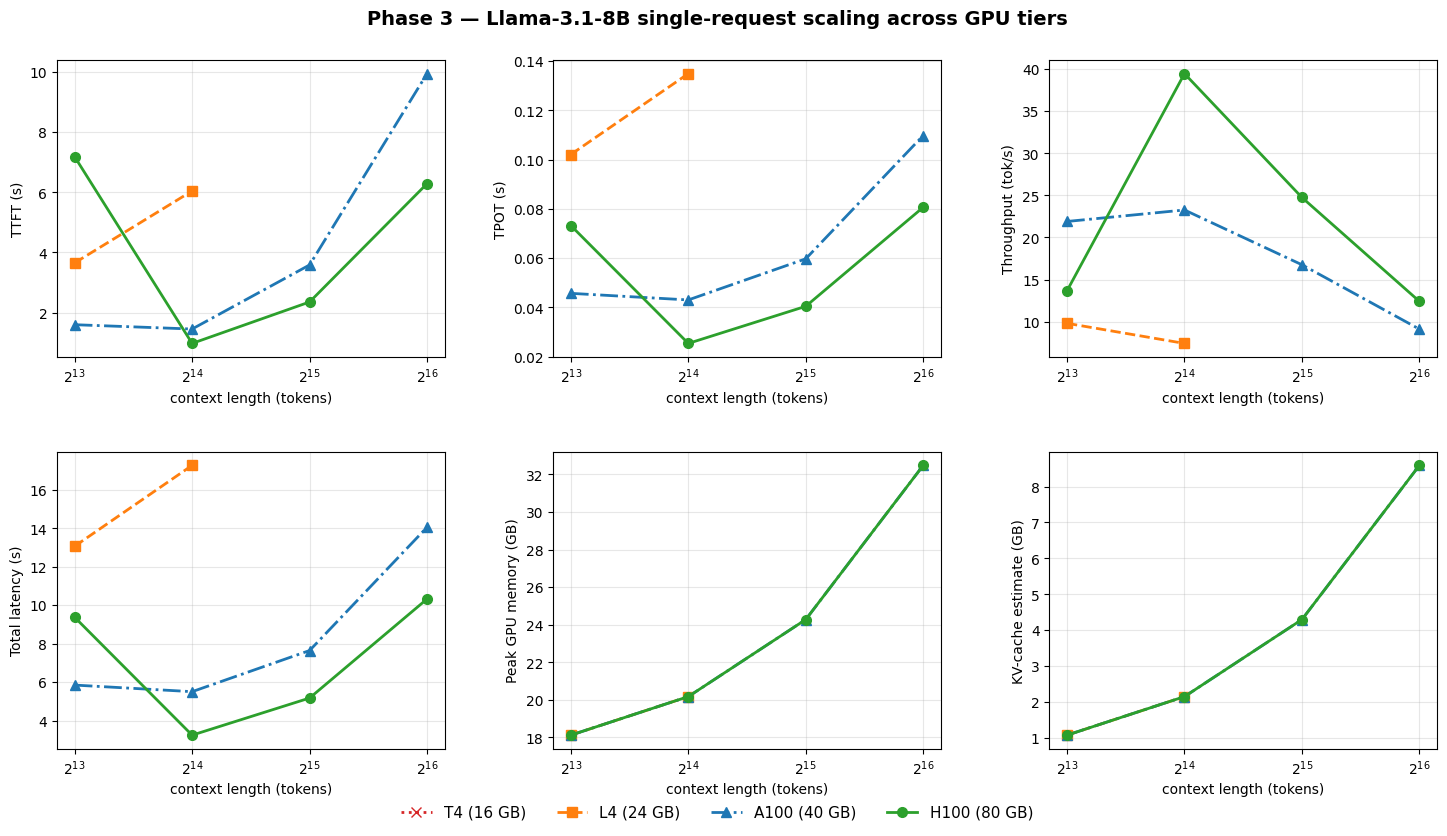

In [11]:
import matplotlib.pyplot as plt

PLOT_DIR = Path('results/plots'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
METRICS = [
    ('ttft_seconds',          'TTFT (s)'),
    ('tpot_seconds',          'TPOT (s)'),
    ('tokens_per_second',     'Throughput (tok/s)'),
    ('total_latency_seconds', 'Total latency (s)'),
    ('peak_gpu_memory_gb',    'Peak GPU memory (GB)'),
    ('kv_cache_memory_gb',    'KV-cache estimate (GB)'),
]

TIER_STYLE = {
    'nvidia_t4':   {'color': '#d62728', 'marker': 'x', 'linestyle': ':',  'label': 'T4 (16 GB)'},
    'nvidia_l4':   {'color': '#ff7f0e', 'marker': 's', 'linestyle': '--', 'label': 'L4 (24 GB)'},
    'nvidia_a100': {'color': '#1f77b4', 'marker': '^', 'linestyle': '-.', 'label': 'A100 (40 GB)'},
    'nvidia_h100': {'color': '#2ca02c', 'marker': 'o', 'linestyle': '-',  'label': 'H100 (80 GB)'},
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
fig.suptitle('Phase 3 — Llama-3.1-8B single-request scaling across GPU tiers',
             fontsize=14, fontweight='bold', y=0.99)
for (col, ylabel), ax in zip(METRICS, axes.flat):
    for hw, grp in sorted(df.groupby('hardware'), key=lambda kv: tier_key(kv[0])):
        style = TIER_STYLE.get(hw, {'color': 'grey', 'marker': '.', 'linestyle': '-', 'label': hw})
        ok = grp[grp.success == True].sort_values('context_length')
        if len(ok):
            ax.plot(ok.context_length, ok[col],
                    color=style['color'], marker=style['marker'],
                    linestyle=style['linestyle'], linewidth=2, markersize=7,
                    label=style['label'])
    ax.set_xscale('log', base=2)
    ax.set_xlabel('context length (tokens)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

legend_handles = [
    plt.Line2D([0], [0], color=TIER_STYLE[hw]['color'], marker=TIER_STYLE[hw]['marker'],
               linestyle=TIER_STYLE[hw]['linestyle'], linewidth=2, markersize=7,
               label=TIER_STYLE[hw]['label'])
    for hw in ['nvidia_t4', 'nvidia_l4', 'nvidia_a100', 'nvidia_h100']
    if hw in df['hardware'].unique()
]

fig.subplots_adjust(left=0.06, right=0.98, top=0.93, bottom=0.12, hspace=0.32, wspace=0.28)
fig.legend(handles=legend_handles, loc='lower center',
           ncol=len(legend_handles), bbox_to_anchor=(0.5, 0.02),
           frameon=False, fontsize=11)

out = PLOT_DIR / 'phase3_hardware_comparison.png'
plt.savefig(out, dpi=120)
print(f'saved {out}')
plt.show()

saved results/plots/phase3_frontier.png


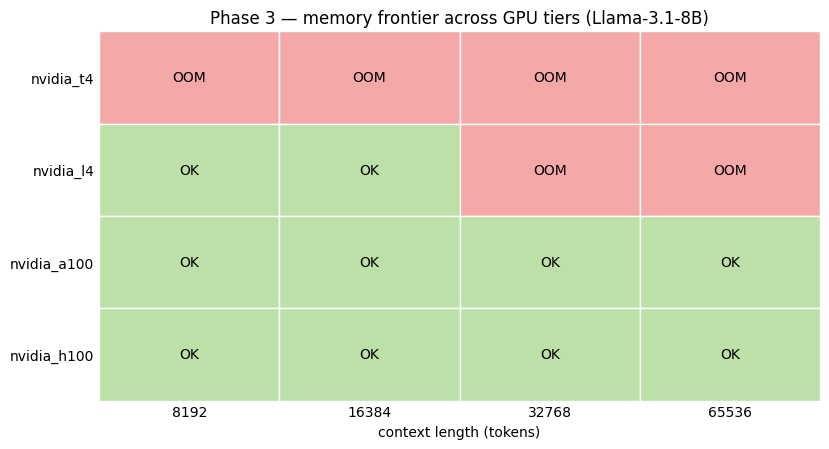

In [9]:
import numpy as np
from matplotlib.patches import Rectangle

pivot_ok = df.pivot_table(index='hardware', columns='context_length',
                          values='success', aggfunc='first')
pivot_ok = pivot_ok.reindex([t for t in TIER_ORDER if t in pivot_ok.index])

fig, ax = plt.subplots(figsize=(1.6 * len(pivot_ok.columns) + 2,
                                 0.9 * len(pivot_ok.index) + 1))
for i, hw in enumerate(pivot_ok.index):
    for j, ctx in enumerate(pivot_ok.columns):
        v = pivot_ok.loc[hw, ctx]
        color = '#bde0a8' if v == True else ('#f4a8a8' if v == False else '#dddddd')
        ax.add_patch(Rectangle((j, i), 1, 1, facecolor=color, edgecolor='white'))
        label = 'OK' if v == True else ('OOM' if v == False else '-')
        ax.text(j + 0.5, i + 0.5, label, ha='center', va='center', fontsize=10)
ax.set_xlim(0, len(pivot_ok.columns)); ax.set_ylim(0, len(pivot_ok.index))
ax.invert_yaxis()
ax.set_xticks(np.arange(len(pivot_ok.columns)) + 0.5); ax.set_xticklabels(pivot_ok.columns)
ax.set_yticks(np.arange(len(pivot_ok.index)) + 0.5);   ax.set_yticklabels(pivot_ok.index)
ax.set_xlabel('context length (tokens)')
ax.set_title('Phase 3 — memory frontier across GPU tiers (Llama-3.1-8B)')
ax.tick_params(length=0)
for spine in ax.spines.values(): spine.set_visible(False)
plt.tight_layout()
out = PLOT_DIR / 'phase3_frontier.png'
plt.savefig(out, dpi=120, bbox_inches='tight')
print(f'saved {out}')
plt.show()